In [1]:
import os
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from astroquery.simbad import Simbad

In [2]:
def read_data(file_path, colour):
    
    # Skip Luminance filter entirely
    if colour.lower() == "luminance":
        return pd.DataFrame()

    try:
        df = pd.read_csv(file_path, usecols=[
            "Saturated", "matched_id", "matched_MAIN_ID",
            "Source_Mag_norm", "Source_Mag_Error_norm", "Air mass"
        ])
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return pd.DataFrame()

    # Keep only rows with a non-empty matched_MAIN_ID
    df = df[(df["Saturated"] != True) & (df["matched_MAIN_ID"].notna()) & (df["matched_MAIN_ID"] != "")]

    # Rename columns
    df = df.rename(columns={
        "matched_MAIN_ID": "star_name",
        "Source_Mag_norm": "instrumental_mag",
        "Source_Mag_Error_norm": "instrumental_mag_err",
        "Air mass": "airmass"
    })

    # Use star_name as the canonical index
    df["star_index"] = df["star_name"]

    # Map filter names to unified B/V/R labels
    filter_map = {
        "Blue": "B_ins",
        "Baader-JC-B": "B_ins",
        "Green": "V_ins",
        "Baader-JC-V": "V_ins",
        "Red": "R_ins",
        "Baader-JC-R": "R_ins"
    }

    if colour not in filter_map:
        print(f"Warning: filter {colour} not recognized, skipping")
        return pd.DataFrame()
    else:
        mapped_filter = filter_map[colour]

    # Rename instrumental_mag, error, and airmass to unified names
    df = df.rename(columns={
        "instrumental_mag": mapped_filter,
        "instrumental_mag_err": f"{mapped_filter}_err",
        "airmass": f"{mapped_filter.split('_')[0]}_airmass"  # e.g. B_airmass, V_airmass, R_airmass
    })

    return df[[
        "star_index", mapped_filter, f"{mapped_filter}_err", f"{mapped_filter.split('_')[0]}_airmass"
    ]]

In [3]:
# Load Landolt catalog
landolt_stars = pd.read_csv("data/landolt_north.csv", delimiter="|")
landolt_stars.columns = ['oid', 'main_id', 'ra', 'dec']
landolt_names = set(landolt_stars["main_id"].str.strip())

def is_landolt(star_name, alt_ids, landolt_names):
    # Check canonical name
    if star_name.strip() in landolt_names:
        return True
    # Check alternative IDs
    if isinstance(alt_ids, list):
        for alt in alt_ids:
            if alt.strip() in landolt_names:
                return True
    return False


In [4]:
# --- Collect all data ---
all_data = []
ZWO_Standard = ["tyc_3466_388_1", "BD+45_2074", "HD_117933"]
JC_Standard = ["GD_410", "HD_23256"]

#Standards = ZWO_Standard
Standards = JC_Standard

for standard in Standards:
    with open(f"Star_Configurations/{standard}.yaml", "r") as f:
        cfg = yaml.safe_load(f)

    file_nights = list(cfg["file_nights"].keys())
    colour_list = cfg['file_nights'][file_nights[0]]["colour_list"]
    base_dir = Path(cfg["base_dir"])

    for night in file_nights:
        for colour in colour_list:
            folder = base_dir / standard / night / "Light" / colour / "photometry_matched_norm"
            for file in os.listdir(folder):
                if file.endswith(".csv"):
                    file_path = folder / file
                    df = read_data(file_path, colour)
                    if not df.empty:
                        df["standard"] = standard
                        df["night"] = night
                        all_data.append(df)

# --- Combine all rows ---
long_df = pd.concat(all_data, ignore_index=True)

# --- Lookup table for star IDs ---
lookup = long_df[["star_index"]].drop_duplicates()

# --- Group by star_index and average the unified columns ---
stars = long_df.groupby("star_index").mean(numeric_only=True).reset_index()

# --- Merge back IDs ---
stars = stars.merge(lookup, on="star_index", how="left")

In [5]:
def get_simbad(stars_df):
    Simbad.TIMEOUT = 60
    Simbad.reset_votable_fields()
    Simbad.add_votable_fields("ids", "otype", "B", "V", "R")

    alt_ids, obj_types = {}, {}
    mags_B, mags_V, mags_R = {}, {}, {}

    for name in stars_df["star_index"]:
        try:
            result = Simbad.query_object(name)
            if result is not None and len(result) > 0:
                result_df = result.to_pandas()
                # Replace masked values with None
                result_df = result_df.apply(lambda col: col.map(lambda x: None if np.ma.is_masked(x) else x))
                row = result_df.iloc[0]

                # Alternative IDs
                alt_ids[name] = row.get("ids", "").split("|") if "ids" in row else []
                # Object type
                obj_types[name] = row.get("otype", None)

                # Magnitudes (SIMBAD columns are just 'B', 'V', 'R')
                mags_B[name] = row.get("B", None)
                mags_V[name] = row.get("V", None)
                mags_R[name] = row.get("R", None)
            else:
                alt_ids[name], obj_types[name] = [], None
                mags_B[name] = mags_V[name] = mags_R[name] = None
        except Exception as e:
            print(f"SIMBAD query failed for {name}: {e}")
            alt_ids[name], obj_types[name] = [], None
            mags_B[name] = mags_V[name] = mags_R[name] = None

    # Add results to DataFrame
    stars_df["alt_ids"] = stars_df["star_index"].map(alt_ids)
    stars_df["object_type"] = stars_df["star_index"].map(obj_types)
    stars_df["B_mag"] = stars_df["star_index"].map(mags_B)
    stars_df["V_mag"] = stars_df["star_index"].map(mags_V)
    stars_df["R_mag"] = stars_df["star_index"].map(mags_R)

    return stars_df

In [6]:
stars = get_simbad(stars)

# Apply check to each row
stars["Landolt"] = stars.apply(
    lambda row: is_landolt(row["star_index"], row["alt_ids"], landolt_names),
    axis=1
)

# Only keeping landolt stars
stars = stars[stars["Landolt"] == True].reset_index(drop=True)

In [7]:
# --- Save final enriched table ---
stars.to_csv("data/combined_standards.csv", index=False)

In [8]:
def model(inputs, a, b, c):
    x_mag, airmass, colour = inputs
    return x_mag + a + b * airmass + c * colour

In [9]:
def compute_colour(df, m1, m2):
    df['colour'] = df[f'{m1}'] - df[f'{m2}']
    df['colour_err'] = np.sqrt(
        df[f'{m1}_err']**2 + df[f'{m2}_err']**2
    )
    return df


In [10]:
def filter_transform(from_filter, to_filter, plot=False):
    # Prepare raw arrays
    x_mag = stars[f"{from_filter}"].values
    x_err = stars[f"{from_filter}_err"].values

    # Apparent (catalogued) magnitudes
    y_mag = stars[f"{to_filter}_mag"].values
    y_err = stars.get(f"{to_filter}_mag_err", np.zeros_like(y_mag)).values \
             if f"{to_filter}_mag_err" in stars.columns else np.zeros_like(y_mag)

    # Airmass per filter (e.g. B_airmass, V_airmass, R_airmass)
    airmass = stars[f"{from_filter.split('_')[0]}_airmass"].values

    colour = stars["colour"].values
    colour_err = stars["colour_err"].values

    # Filtering: ensure all inputs and errors are finite
    valid_mask = (
        np.isfinite(x_mag) &
        np.isfinite(x_err) &
        np.isfinite(airmass) &
        np.isfinite(colour) &
        np.isfinite(colour_err) &
        np.isfinite(y_mag) &
        np.isfinite(y_err)
    )

    # Apply mask and clean arrays
    x_mag_clean = x_mag[valid_mask]
    x_err_clean = np.abs(x_err[valid_mask])
    airmass_clean = airmass[valid_mask]
    colour_clean = colour[valid_mask]
    colour_err_clean = np.abs(colour_err[valid_mask])
    y_mag_clean = y_mag[valid_mask]
    y_err_clean = np.abs(y_err[valid_mask])
    inputs_clean = (x_mag_clean, airmass_clean, colour_clean)

    # Combine errors for weighting
    total_err_clean = np.sqrt(x_err_clean**2 + y_err_clean**2 + colour_err_clean**2)

    # Fit the model with weights
    params, covariance = curve_fit(
        model,
        inputs_clean,
        y_mag_clean,
        p0=[1, 1, 1],
        sigma=total_err_clean,
        absolute_sigma=True
    )

    a_fit, b_fit, c_fit = params
    a_err, b_err, c_err = np.sqrt(np.diag(covariance))

    # --- χ² calculation ---
    y_pred = model(inputs_clean, *params)
    residuals = y_mag_clean - y_pred
    chi2 = np.sum((residuals / total_err_clean)**2)
    dof = len(y_mag_clean) - len(params)
    reduced_chi2 = chi2 / dof if dof > 0 else np.nan

    if plot:
        rhs = x_mag_clean + a_fit + b_fit * airmass_clean + c_fit * colour_clean
        lhs = y_mag_clean

        # Fit plot
        plt.figure(figsize=(8, 5))
        plt.errorbar(rhs, lhs, xerr=total_err_clean, yerr=y_err_clean,
                     fmt='o', capsize=3, label='Data with errors')
        plt.plot(rhs, y_pred, 'r-', label='Fitted Line')
        plt.title(f"Filter Transformation: {from_filter} (instrumental) → {to_filter} (apparent)\n"
                  f"Chi^2 = {chi2:.2f}, reduced Chi^2 = {reduced_chi2:.2f}")
        plt.xlabel(f"Predicted apparent magnitude from {from_filter} + a + (b × airmass) + (c × colour)")
        plt.ylabel(f"Catalogued apparent magnitude in {to_filter}")
        plt.legend()
        plt.grid(True)
        plt.gca().invert_xaxis()
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # Residuals plot
        delta_mag = residuals
        plt.figure(figsize=(8, 5))
        plt.errorbar(y_mag_clean, delta_mag, xerr=y_err_clean, yerr=total_err_clean,
                     fmt='o', capsize=3, label='Residuals')
        plt.axhline(0, color='r', linestyle='--', label='Zero residual')
        plt.title(f"Residuals: {from_filter} (instrumental) → {to_filter} (apparent)")
        plt.xlabel(f"Catalogued apparent magnitude in {to_filter}")
        plt.ylabel("Residual (measured − predicted)")
        plt.legend()
        plt.grid(True)
        plt.gca().invert_xaxis()
        plt.tight_layout()
        plt.show()

    print(f"Fitted parameters:\n"
          f"a = {a_fit:.4f} ± {a_err:.4f}, "
          f"b = {b_fit:.4f} ± {b_err:.4f}, "
          f"c = {c_fit:.4f} ± {c_err:.4f}, "
          f"chi^2 = {chi2:.2f}, reduced chi^2 = {reduced_chi2:.2f}\n")

    return a_fit, b_fit, c_fit, a_err, b_err, c_err, chi2, reduced_chi2


In [11]:
# --- Compute colours ---
stars = compute_colour(stars, 'B_ins', 'V_ins')
#stars = compute_colour(stars, 'B_ins', 'R_ins')
#stars = compute_colour(stars, 'V_ins', 'R_ins')

# --- Define filter sets ---
ins_mags = ["B_ins", "V_ins", "R_ins"]   # unified instrumental filters
apparent_mag = ["B", "V", "R"]           # catalogued JC bands

# --- Loop through transformations ---
transform_results = []
for filter_out in apparent_mag:       # JC bands
    for filter_in in ins_mags:        # instrumental filters
        a, b, c, a_err, b_err, c_err, chi2, red_chi2 = filter_transform(filter_in, filter_out, plot=True)
        transform_results.append({
            "filter_from": filter_in, "filter_to": filter_out,
            "a": a, "a_err": a_err,
            "b": b, "b_err": b_err,
            "c": c, "c_err": c_err,
            "chi2": chi2,
            "reduced_chi2": red_chi2
        })

# --- Save results ---
transform_df = pd.DataFrame(transform_results)
transform_df.to_csv("data/conversion_data/calibration_factors.csv", index=False)

Fitted parameters:
a = 19.8326 ± 0.1622, b = 0.0102 ± 0.0284, c = 0.1280 ± 0.0050, chi^2 = 391.20, reduced chi^2 = 24.45

Fitted parameters:
a = -405.6573 ± 4744838861.1565, b = 74.7863 ± 833867678.9355, c = 1.1274 ± 0.0045, chi^2 = 384.37, reduced chi^2 = 24.02

Fitted parameters:
a = -406.6557 ± 4496486940.1232, b = 74.7462 ± 789146070.2993, c = 1.6365 ± 0.0049, chi^2 = 475.92, reduced chi^2 = 29.74

Fitted parameters:
a = 19.9208 ± 0.1622, b = 0.0174 ± 0.0284, c = -0.9640 ± 0.0050, chi^2 = 169.10, reduced chi^2 = 10.57

Fitted parameters:
a = -1231.8969 ± 10163107288.4115, b = 220.0144 ± 1786085253.7300, c = 0.0345 ± 0.0045, chi^2 = 198.86, reduced chi^2 = 12.43

Fitted parameters:
a = -406.5905 ± 8750086941.7541, b = 74.7577 ± 1535664778.4389, c = 0.5384 ± 0.0050, chi^2 = 256.81, reduced chi^2 = 16.05

Fitted parameters:
a = 20.2521 ± 0.1622, b = -0.0257 ± 0.0284, c = -1.6257 ± 0.0050, chi^2 = 391.84, reduced chi^2 = 24.49

Fitted parameters:
a = -818.6500 ± 12065784469.1321, b = 1

# Calibration Factor check

In [12]:
# Load factor files

files = [
    "ZWO_Blue-Green_calibration_factors.csv",
    "ZWO_Blue-Red_calibration_factors.csv",
    "ZWO_Green-Red_calibration_factors.csv"
]


filter_factors_dfs = []
for f in files:
    df = pd.read_csv(base_dir / "conversion_data" / f)
    colour = f.split("_")[1]
    df['colour'] = colour
    filter_factors_dfs.append(df)

# Concatenate
filter_factors = pd.concat(filter_factors_dfs, ignore_index=True)



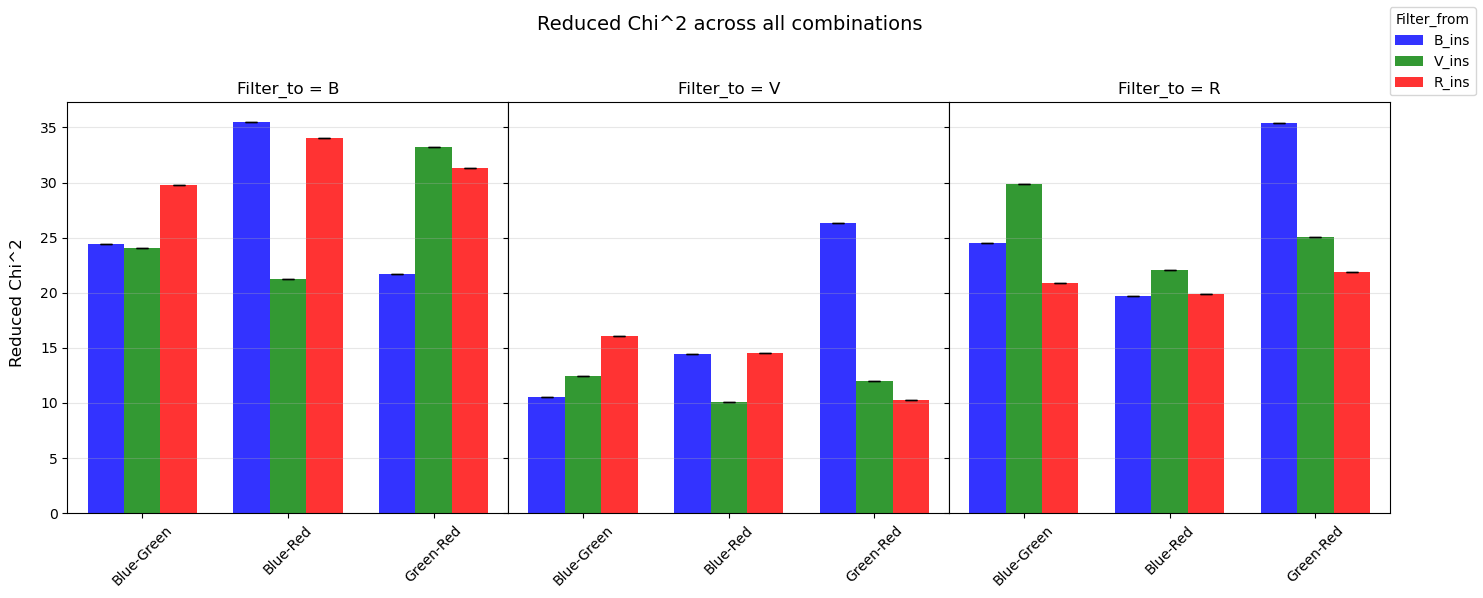

In [15]:
# --- Setup for faceted bar chart ---
filter_to_values = filter_factors['filter_to'].unique()
fig, axes = plt.subplots(1, len(filter_to_values), figsize=(15, 6), sharey=True,
                         gridspec_kw={'wspace': 0})

width = 0.25
colours = filter_factors['colour'].unique()
filter_froms = filter_factors['filter_from'].unique()
x = np.arange(len(colours))

# Define colour mapping for filter_from
colour_map = {
    'B_ins': 'blue',
    'V_ins': 'green',
    'R_ins': 'red'
}

# --- Plot bars with error bars ---
for ax, filter_to in zip(axes, filter_to_values):
    subdf = filter_factors[filter_factors['filter_to'] == filter_to]

    for i, f_from in enumerate(filter_froms):
        # Group by colour to avoid duplicate index issues
        df_plot = (
            subdf[subdf['filter_from'] == f_from]
            .groupby('colour').mean(numeric_only=True)
            .reindex(colours)
        )

        heights = df_plot['reduced_chi2'].values
        errors = 0.0 #df_plot['a_err'].values

        ax.bar(x + i*width, heights, width,
               label=f_from,
               yerr=errors,
               capsize=4,
               alpha=0.8,
               color=colour_map.get(f_from, 'gray'))

    ax.set_xticks(x + width)
    ax.set_xticklabels(colours, rotation=45)
    ax.set_title(f"Filter_to = {filter_to}")
    ax.grid(axis='y', alpha=0.3)
    
"""

    # --- Highlight best reduced χ² per colour group ---
    for colour in colours:
        group = subdf[subdf['colour'] == colour]
        if not group.empty:
            best_row = group.loc[group['reduced_chi2'].idxmin()]
            f_from = best_row['filter_from']
            xpos = list(filter_froms).index(f_from)
            xval = x[list(colours).index(colour)] + xpos * width
            yval = best_row['reduced_chi2']

            ax.text(xval, yval + 0.05, "*",
                    ha='center', va='bottom',
                    fontsize=16, fontweight='bold',
                    color='black',
                    path_effects=[path_effects.withStroke(linewidth=3, foreground='white')])

"""

# --- Shared y-axis label and single legend ---
fig.text(0.02, 0.5, "Reduced Chi^2", va='center', rotation='vertical', fontsize=12)
fig.suptitle("Reduced Chi^2 across all combinations", fontsize=14)

# Grab handles/labels from the last axis
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Filter_from", loc="upper right")

plt.tight_layout(rect=[0.03, 0, 0.95, 0.95])
plt.show()


In [14]:
#filter_factors.to_csv("data/conversion_data/all_ZWO_calibration_factors.csv", index=False)